# Part 3: ResNet-18 Tile Order Hardness Analysis

This notebook reuses the Part 1 ResNet-18 baseline results and saved tile permutations to compute tile permutation hardness metrics without retraining.

In [1]:
from pathlib import Path
import importlib
import os
import sys

In [2]:
current = Path.cwd().resolve()
for candidate in [current, *current.parents]:
    if (candidate / 'src').is_dir() and (candidate / 'requirements.txt').exists():
        ROOT = candidate
        break
else:
    ROOT = current

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

In [3]:
def install_project_requirements_for_colab(project_root: Path) -> None:
    """Install non-PyTorch dependencies in Colab without replacing CUDA-matched torch wheels."""
    try:
        import google.colab  # type: ignore  # noqa: F401
    except ImportError:
        return

    import subprocess

    requirements_path = project_root / 'requirements.txt'
    filtered_requirements = Path('/tmp/mlds_colab_requirements.txt')
    skip_prefixes = ('torch', 'torchvision')
    filtered_lines = [
        line
        for line in requirements_path.read_text().splitlines()
        if not line.strip().lower().startswith(skip_prefixes)
    ]
    filtered_requirements.write_text('\n'.join(filtered_lines) + '\n')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(filtered_requirements)])


In [4]:
install_project_requirements_for_colab(ROOT)

ROOT

PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project')

In [5]:

import pandas as pd
from IPython.core.display import Image
from IPython.display import display

import src.evaluation.tile_permutation_difficulty as tile_permutation_difficulty
import src.evaluation.experiment_results as experiment_results
import src.utils.config as config_module

config_module = importlib.reload(config_module)
tile_permutation_difficulty = importlib.reload(tile_permutation_difficulty)
experiment_results = importlib.reload(experiment_results)
Part3ExperimentConfig = config_module.Part3ExperimentConfig
load_part1_model_results = experiment_results.load_part1_model_results
load_part3_results = experiment_results.load_part3_results
part3_output_paths = experiment_results.part3_output_paths
run_part3_hardness_analysis = experiment_results.run_part3_hardness_analysis


/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## Configuration
Define Part 3 settings in `Part3ExperimentConfig`, reusing the Part 1 model/data/tile permutation outputs.


In [6]:

config = Part3ExperimentConfig()
results_dir = Path(config.results_dir)
figures_dir = Path(config.figures_dir)
part1_results_csv = results_dir / 'part1_raw_results.csv'
tile_permutation_csv = results_dir / 'part1_tile_permutations.csv'
output_paths = part3_output_paths(str(results_dir), str(figures_dir))

pd.DataFrame([
    {
        'part': config.part,
        'config_name': config.config_name,
        'model_name': config.model_name,
        'tiles_per_side_values': config.tiles_per_side_values,
        'num_tile_permutations': config.num_tile_permutations,
        'seed': config.seed,
        'alpha_center': config.alpha_center,
        'weight_center': config.weight_center,
        'weight_dist': config.weight_dist,
    }
])


,part,config_name,model_name,tiles_per_side_values,num_tile_permutations,seed,alpha_center,weight_center,weight_dist
0,part3,part3_hardness_analysis,resnet18,"[1, 3]",2,42,1.0,0.5,0.5


In [7]:

METRIC_LABELS = {
    'global_tile_displacement': 'Global displacement',
    'center_weighted_displacement': 'Center-weighted displacement',
    'combined_hardness_score': 'Combined hardness',
}
METRIC_COLUMNS = list(METRIC_LABELS)


def display_part3_metrics_table(metrics: pd.DataFrame, max_rows: int = 12):
    table = metrics.copy()
    table['_reordered_first'] = ~((table['tiles_per_side'] == 1) | (table['tile_permutation_id'] == 0))
    table = table.sort_values(['_reordered_first', 'tiles_per_side', 'tile_permutation_id'], ascending=[False, True, True])
    table = table.drop(columns=['_reordered_first'])
    table = table.rename(columns=METRIC_LABELS | {
        'tiles_per_side': 'Grid',
        'num_tiles': 'Tiles',
        'tile_permutation_id': 'Tile Order',
        'tile_permutation_seed': 'Seed',
    })
    display(table.head(max_rows).style.format(precision=3))


def display_part3_joined_table(joined: pd.DataFrame, max_rows: int = 12):
    columns = ['tiles_per_side', 'num_tiles', 'tile_permutation_id', 'best_val_accuracy', *METRIC_COLUMNS]
    table = joined.loc[:, [column for column in columns if column in joined.columns]].copy()
    table['_reordered_first'] = ~((table['tiles_per_side'] == 1) | (table['tile_permutation_id'] == 0))
    table = table.sort_values(['_reordered_first', 'tiles_per_side', 'tile_permutation_id'], ascending=[False, True, True])
    table = table.drop(columns=['_reordered_first'])
    table = table.rename(columns=METRIC_LABELS | {
        'tiles_per_side': 'Grid',
        'num_tiles': 'Tiles',
        'tile_permutation_id': 'Tile Order',
        'best_val_accuracy': 'Best validation accuracy',
    })
    display(table.head(max_rows).style.format(precision=3))


def display_part3_correlations_table(correlations: pd.DataFrame):
    table = correlations.copy()
    table['metric'] = table['metric'].replace(METRIC_LABELS)
    table = table.rename(columns={
        'group': 'Group',
        'metric': 'Metric',
        'pearson': 'Pearson',
        'spearman': 'Spearman',
        'n': 'N',
    })
    display(table.style.format({'Pearson': '{:.3f}', 'Spearman': '{:.3f}'}))


## Data Loading
Load existing Part 1 results filtered to the configured Part 3 model.

In [8]:

part1_model_results = load_part1_model_results(str(part1_results_csv), config.model_name)
print(f'Part 1 {config.model_name} result rows: {len(part1_model_results)}')
display(
    part1_model_results[
        ['tiles_per_side', 'num_tiles', 'tile_permutation_id', 'best_val_accuracy']
    ].sort_values(['tiles_per_side', 'tile_permutation_id']).head(12).style.format(precision=3)
)


Part 1 resnet18 result rows: 3


,tiles_per_side,num_tiles,tile_permutation_id,best_val_accuracy
1,3.000,9,1,0.885
2,3.000,9,2,0.788
0,nan,1,0,0.865


## Compute Hardness Metrics
Compute tile permutation-only metrics, join them with ResNet-18 accuracy, and save outputs.

In [9]:

analysis_results = run_part3_hardness_analysis(
    results_dir=str(results_dir),
    figures_dir=str(figures_dir),
    part1_results_csv=str(part1_results_csv),
    tile_permutation_csv=str(tile_permutation_csv),
    tiles_per_side_values=config.tiles_per_side_values,
    num_tile_permutations=config.num_tile_permutations,
    seed=config.seed,
    alpha_center=config.alpha_center,
    weight_center=config.weight_center,
    weight_dist=config.weight_dist,
    model_name=config.model_name,
    verbose=True,
    show_progress=True,
)

display_part3_metrics_table(analysis_results['metrics'])
display_part3_joined_table(analysis_results['joined'])


Preparing Part 3 output directories...
Loading or rebuilding Part 1 tile permutations...
Calculating hardness metrics...


Part 3 metrics: 100%|██████████| 3/3 [00:00<00:00, 202.18tile permutation/s]

Saving hardness metric table...
Loading Part 1 resnet18 results...
Joining hardness metrics with resnet18 accuracy...
Saving joined metric-accuracy table...
Computing metric-accuracy correlations...


Saving correlations and plots...
Part 3 hardness analysis complete.


,Grid,Tiles,Tile Order,Seed,Global displacement,Center-weighted displacement,adjacency_destruction_hardness,Combined hardness
1,3.000,9,1,42,0.833,0.787,0.833,0.810
2,3.000,9,2,42,0.583,0.678,1.000,0.631
0,nan,1,0,42,0.000,0.000,0.000,0.000


,Grid,Tiles,Tile Order,Best validation accuracy,Global displacement,Center-weighted displacement,Combined hardness
1,3.000,9,1,0.885,0.833,0.787,0.810
2,3.000,9,2,0.788,0.583,0.678,0.631
0,nan,1,0,0.865,0.000,0.000,0.000


## Correlations
Display Pearson and Spearman correlations between each hardness metric and the configured model validation accuracy.

In [10]:
saved_results = load_part3_results(str(results_dir))
display_part3_correlations_table(saved_results['correlations'])

if saved_results['correlations'][['pearson', 'spearman']].isna().any().any():
    print(
        'NaN means the correlation is undefined because the selected accuracy '
        'or metric values are constant in the joined Part 3 data.'
    )


,Group,Metric,Pearson,Spearman,N
0,resnet18,Global displacement,-0.037,0.500,3
1,resnet18,Center-weighted displacement,-0.204,0.500,3
2,resnet18,adjacency_destruction_hardness,-0.470,-0.500,3
3,resnet18,Combined hardness,-0.121,0.500,3


## Metric Plots
Display saved metric-vs-accuracy plots.

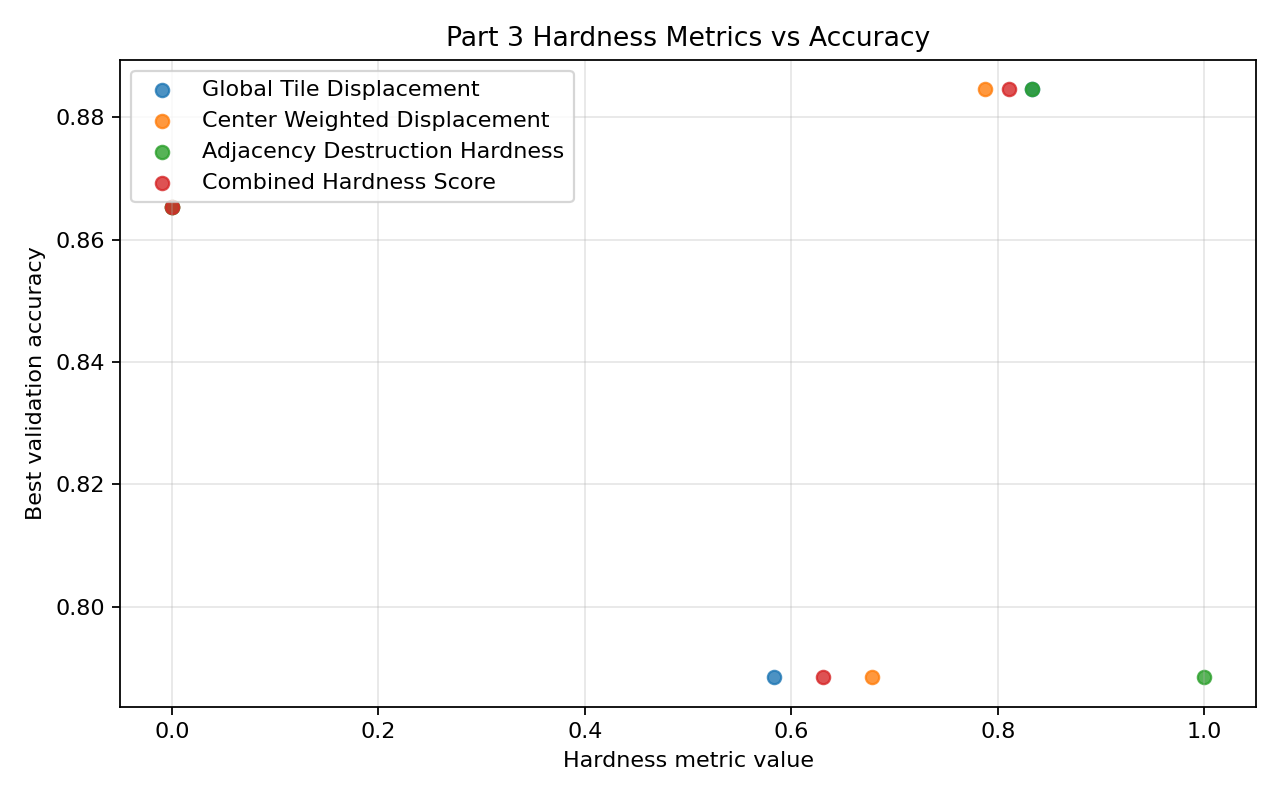

In [11]:
output_paths = part3_output_paths(str(results_dir), str(figures_dir))
for figure_path in output_paths['plots']:
    display(Image(filename=figure_path))
if not output_paths['plots']:
    print('No Part 3 plots found yet.')